# Обработчик опросов
Определим порядок в котором мы будем обрабатывать данные из опроса:
 1. Нормализуем опрос к одной форме : тк опрашиваемый в опросе отвечает на вопросы по нескольким мерам, то мы создаем минимальную единицу в виде строки в которой будет связка опрашиваемый + мера в определенном городе
 2. Категориальные понятия, такие как оценка меры словами, мы приводим к числовым значениям: "Сильно выражено", "Слабо выражено" в 3 и 1 соответственно
 3. Данные, где был ответ "Затрудняюсь ответить" мы нормализуем, как среднее для данной меры в данном городе
 4. Строим нейронную сеть  и обучаем её
 5. Накидываем нейронке различные сценарии, чтобы получить инсайты
 
 

In [1]:
# тут прописаны библиотеки, с которыми нам предстоит работать
import pandas as pd # база для работы с данными
import random # рандомизация
import os # для работы с операционкой, в нашем случае, чтобы читать и записывать файлы
import re # библиотека, которая позволяет находить строки по опрделнной маске написанной на языке RegEx
import numpy as np # база для работы с данными
from tensorflow.keras.models import Sequential # эти 4 библиотеки нужны для создания нейронки
from tensorflow.keras.layers import Dense
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split 
import matplotlib.pyplot as plt


In [2]:
#Забираем ответы на форму

filename = r'D:\Documents\учеба\НИР ответы.xlsx' # Имя файла с ответами на опросы

sheet_name =r'Ответы на форму (1)' # Лист с ответамии

global df # Определяем глобальную переменную, не обязательно глобальную, это признаки хорошего кода))
df_clean = pd.read_excel(filename, sheet_name) # читаем файл
df = df_clean # копируем исходник, чтобы у нам был чистый исходник, к которому мы можем потом обратиться

In [3]:
df # Чекаем то ли мы забрали

,Отметка времени,"1. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: расходы государства [Приватизация]","1. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: расходы государства [ГЧП + Приватизация + Меры фин. поддержки]","1. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: расходы государства [ГЧП + Приватизация]","1. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: расходы государства [ГЧП + Аренда]","1. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: расходы государства [ГЧП + Аренда + Меры фин. поддержки]","1. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: расходы государства [Безвозмездная передача + Приватизация]","1. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: расходы государства [Безвозмездная передача + Аренда]","1. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: расходы государства [Безвозмездная передача + Меры фин. поддержки]","1. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: расходы государства [Безвозмездная передача + Приватизация + Меры фин. поддержки ]",...,"Дайте общую оценку применению каждой из мер поддержки, если данная мера отсутствует в вашем регионе, ставьте «Не применяется» [Безвозмездная передача + Аренда]","Дайте общую оценку применению каждой из мер поддержки, если данная мера отсутствует в вашем регионе, ставьте «Не применяется» [Безвозмездная передача + Меры фин. поддержки]","Дайте общую оценку применению каждой из мер поддержки, если данная мера отсутствует в вашем регионе, ставьте «Не применяется» [Безвозмездная передача + Приватизация + Меры фин. поддержки ]",Являетесь ли Вы практикующим специалистом в области архитектуры / девелопмента / работы с культурным наследием?,Укажите Ваш регион работы или проживания,ФИО,Должность,Хотели бы Вы получить результат данного исследования в виде отчёта?,Разрешаете ли Вы использование персональных данных (ФИО и должность) в публичном отчёте?,В случае возникновения вопросов в ходе подготовки отчёта можно ли будет обратиться к Вам повторно?
0,2024-12-27 07:42:22.309,Слабо выражено,Средне выражено,Слабо выражено,Средне выражено,Слабо выражено,Слабо выражено,Слабо выражено,Средне выражено,Средне выражено,...,Неэффективно,Неэффективно,Частично эффективно,Да,Астраханская область,Исаева Н.В,Старший преподаватель,Нет,Нет,Нет
1,2024-12-27 07:43:37.978,Слабо выражено,Слабо выражено,Слабо выражено,Слабо выражено,Отсутствует полностью,Отсутствует полностью,Отсутствует полностью,Отсутствует полностью,Отсутствует полностью,...,Неэффективно,Не применяется,Не применяется,Да,Астраханская область,Цитман Т.О.,доцент архитектурного факультета,Да,Нет,Да
2,2025-01-09 15:31:13.649,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,...,Не применяется,Не применяется,Не применяется,Да,Санкт-Петербург,Голубева Ирина Анатольевна,"Ведущий архитектор, ГАП",Да,Нет,Да
3,2025-01-14 11:41:04.056,Слабо выражено,Слабо выражено,Слабо выражено,Отсутствует полностью,Отсутствует полностью,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,...,Частично эффективно,Не применяется,Не применяется,Да,Вологодская область,Платонова Татьяна,медиатехнолог,Да,Нет,Да
4,2025-01-19 20:23:28.706,Слабо выражено,Затрудняюсь ответить,Средне выражено,Слабо выражено,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,Затрудняюсь ответить,...,Не применяется,Не применяется,Не применяется,Да,Нижегородская область,Шуршев Т.В.,NaN,Нет,Нет,Нет
5,2025-01-19 20:52:29.568,Слабо выражено,Сильно выражено,Средне выражено,Слабо выражено,Средне выражено,Слабо выражено,Слабо выражено,Средне выражено,Сильно выражено,...,Э

In [4]:
#разворачиваем таблицу, чтобы обработать вопросы и выполнить пункт 1
# melt делает следующее var_name будет означать названия столбцов из исходного таблицы, value_name - значения в этих столбцах
df = pd.melt(df, 
            value_vars= df.columns, 
            var_name= 'Вопросы' ,
            value_name= 'Ответы')

In [5]:
# Разбираем вопросы на вопросы и меры
# тут есть немножко мертвого кода, по факту отсюда нам интересны только arr_ONLY_MERA и arr_quest
arr_quest = [] # массив в который будем записывать вопросы, в новой форме, где будут чисто вопросы без входящих в них мер
arr_ONLY_MERA = [] # массив в который будем записывать меры, но в формате со скобками [] 
arr_re_new = []
for s in df['Вопросы']:
    start = s.find('[')  # find возвращает позицию с начала строки, 
    end = s.rfind(']') +1  # rfind возвращает позицию с конца строки
    arr_quest.append(s[0:start]) # вписываем в конец массива новое значение
    if not re.search(r'.*\[.*\].*',s): # с помощью RegEX проверяем  факт отсутствия меры, то есть отсутствия скобок [] 
        arr_re_new.append(0)         # вписываем в конец массива новое значение
    else: # сценарий, когда есть мера, наличие скобок  [] 
        arr_re_new.append(1) # вписываем в конец массива новое значение
        arr_ONLY_MERA.append( s[start:end]) # вписываем в конец массива новое значение
df['Вопрос'] = arr_quest # создаем новый столбец и передаем в него значения массива


In [6]:
# собираем новый фрейм на основе выделенных мер и вопросов
def get_unique_numbers(numbers): # это функция, которая оставляет в массиве numbers только уникальные значения
    unique = [] # создали новый массив, в который будем вписывать уникальные значения
    for number in numbers: # пробегаемся по всем элементам массива
        if number in unique: # проверяем есть ли текущий элемент среди уникальных
            continue # при наличии переходим к следующему элементу
        else: # сценарий при отсутствии текущего элемента среди уникальных
            unique.append(number) # добавляем текущий элемент к уникальным
    return unique # как итог возвращаем массив уникальных элементов массива  numbers
#a = get_unique_numbers(arr_quest) # возвращаем массив уникальных элементов массива  arr_quest, уникальные вопросы
b = get_unique_numbers(arr_ONLY_MERA) # возвращаем массив уникальных элементов массива  arr_ONLY_MERA, уникальные меры
#a.append('МЕРА') #  в дальнейшем все существующие вопросы станут столбцами, надо добавить к ним столбец с мерами
#arr_df = []
#arr_df.append(a)
arr_quest_bez_mer =[] # массив, куда будем складывать вопросы в которых нет мер, по городу и опрашиваемому
df = df_clean # копируем исходную таблицу

# цикл для выделения столбцов без мер
for s in range(len(df.columns)):# пробегаемся по столбцам исходной таблицы
    #count = 0 #  создали счетчик
    for j in range(len(b)): # пробегаемся по всем существующим мерам
        if b[j] in df.columns[s]: # проверяем на наличие меры в текущем столбце исходной таблицы
            #count = 1 
            break # переходим к следующему столбцу, если в этом столбце есть мера
        if j == len(b)-1: # проверка на то, что мы прошлись по всем мерам для текщего столбца
            arr_quest_bez_mer.append(df.columns[s]) # добавляем текущий столбец в массив с вопросами без мер
df_t = pd.DataFrame(columns = arr_quest_bez_mer) # создаем отдельную таблицу, где есть вопросы без мер
for i in df_t.columns: # в этом цикле передаем значения таблицы
    df_t[i] = df[i] # вопросы, где нет меры

df_new = pd.DataFrame(columns = arr_quest_bez_mer)  # создаем таблицу к которой будем присоединять все другие
for j in range(len(b)): # пробегаемся по всем существующим мерам
    count = 0 #  создали счетчик
    df_tmp =df_t # обращ таблицы с вопросами без мер, там вопросы по региону и опрашиваему, а эти данные должны мноижться
    for s in range(len(df.columns)): # пробегаемся по столбцам исходной таблицы
        if b[j] in df.columns[s]: # проверяем на наличие меры в текущем столбце исходной таблицы
            df_tmp[df.columns[s][0:df.columns[s].find('[')]] = df[df.columns[s]] # новое название столбца без меры, куда
                                                                                #  мы передаем значения из исходной таблицы
            df_tmp['МЕРА'] = b[j] # в столбец МЕРА передаем меру 
    df_new = pd.concat([df_new, df_tmp]) # присоединяем к таблице таблицу с данными для текущей меры 
df_new.reset_index(inplace=True) # обнуляем индексы, чтобы они снова стали порядковыми числами


In [7]:
# Пункт 2. даем баллы оценке и оставляем только те меры, которые применяются
df_drop = df_new.loc[df_new.iloc[:,-1].isin(['Не применяется'])]
df_new = df_new.drop(df_drop.index)
df_new = df_new.replace('Сильно выражено', 3)
df_new = df_new.replace('Средне выражено', 2)
df_new = df_new.replace('Слабо выражено', 1)
df_new = df_new.replace('Отсутствует полностью', 0)
df_new = df_new.replace('Существенный', 3)
df_new = df_new.replace('Умеренный', 2)
df_new = df_new.replace('Незначительный', 1)
df_new = df_new.replace('Высокий', 3)
df_new = df_new.replace('Средний', 2)
df_new = df_new.replace('Низкий', 1)
df_new = df_new.replace('Благополучное', 3)
df_new = df_new.replace('Удовлетворительное', 2)
df_new = df_new.replace('Критическое', 1)
#df_new = df_new.replace('Затрудняюсь ответить', pd.NA)



In [8]:
# Пункт 3. усредняем отсутствующие значения 

# передаем значения из текущей таблицы, но если где-то есть не число, то оно становится 0
df_to_acc = df_new.apply(pd.to_numeric, errors='coerce') 

# возвращаем значения мер и регионов
df_to_acc['МЕРА'] = df_new['МЕРА']
df_to_acc['Укажите Ваш регион работы или проживания '] = df_new['Укажите Ваш регион работы или проживания ']

# создаем таблицу, где будут средние значения по мере и региону
df_acc =  df_to_acc.groupby(['МЕРА','Укажите Ваш регион работы или проживания ']).mean() 
df_acc.reset_index(inplace=True)

# создаем таблицу, где будут средние значения по мере и региону отдельно, и выгружаем их, это понадоится при тестировании
df_mean_mer = pd.DataFrame
df_mean_region  = pd.DataFrame
df_mean_mer= df_to_acc.groupby(['МЕРА']).mean()
df_mean_mer.reset_index(inplace=True)
df_mean_mer.to_excel(r'D:\Documents\учеба\средние значения по мере.xlsx', index = False)
df_mean_region= df_to_acc.groupby(['Укажите Ваш регион работы или проживания ']).mean()
9df_mean_region.to_excel(r'D:\Documents\учеба\средние значения по региону.xlsx', index = False)

# в таблице df_new заменяем отсутствующие значения на средние по мере и региону, а в случае отсутствия, то на средние по вопросу
for i in range(len(df_new.columns)):
    for j in df_new.index:    
        if 'Затрудняюсь ответить' == df_new.loc[j,str(df_new.columns[i])]:
            for k in range(len(df_acc)):
                if df_acc.iloc[k,0] == df_new.loc[j, 'МЕРА'] and df_acc.iloc[k,1] == df_new.loc[j, 'Укажите Ваш регион работы или проживания ']:
                    if str(df_acc.loc[k,str(df_new.columns[i])]) == 'nan':
                        # заменяем отсутствующие значения на средние по вопросу
                        df_acc_nan = df_acc[str(df_new.columns[i])]
                        df_new.loc[j,str(df_new.columns[i])] = df_acc_nan.mean()
                    else:
                        # заменяем отсутствующие значения на средние по мере и региону
                        df_new.loc[j,str(df_new.columns[i])] = df_acc.loc[k,str(df_new.columns[i])]
                    break


In [9]:
# выгружаем то, что получилось
df_new.to_excel(r'D:\Documents\учеба\НИР new.xlsx', index = False)


In [10]:
# убираем все данные, которые не нужны нейронке
arr_to_drop = ['index','Отметка времени','Место работы', 'Стаж в сфере работы с объектами культурного наследия ', 'МЕРА',
               'В случае ответа «Да» на предыдущий вопрос, оставьте удобный контакт для связи',
               'Нажимая кнопку “Отправить”, я соглашаюсь на обработку персональных данных',
               'Являетесь ли Вы практикующим специалистом в области архитектуры / девелопмента / работы с культурным наследием?',
               'Укажите Ваш регион работы или проживания ', 'ФИО', 'Должность', 
               'Хотели бы Вы получить результат данного исследования в виде отчёта? ',
               'Разрешаете ли Вы использование персональных данных (ФИО и должность) в публичном отчёте? ',
               'В случае возникновения вопросов в ходе подготовки отчёта можно ли будет обратиться к Вам повторно?', 
              ]
df_new = df_new.drop(arr_to_drop, axis =1)
df_new

,Как Вы оцениваете экономическое состояние вашего региона?,Как Вы оцениваете сохранение историко-культурных ценностей в вашем регионе?,"Как Вы оцениваете состояние инфраструктуры (дороги, общественный транспорт, коммуникации) в вашем регионе?",Как Вы оцениваете развитие туризма в вашем регионе?,Как Вы оцениваете уровень осведомленности населения вашего региона об объектах культурного наследия?,Как Вы оцениваете уровень активности волонтерских движений или НКО в сфере работы с объектами культурного наследия в вашем регионе?,Как Вы оцениваете вклад власти в работу с объектами культурного наследия в вашем регионе?,Как Вы оцениваете вклад бизнеса в работу с объектами культурного наследия в вашем регионе?,"1. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: расходы государства","2. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: доходы государства",...,"4. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: гарантии (для инвесторов)","5. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: риски (для государства)","6. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: риски (для инвесторов)","7. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: дальнейшее использование объекта","8. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: гарантия качества восстановления объекта","9. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: фактический объем восстановления (выражается в количестве качественно восстановленных объектов)","10. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: потенциальный объем восстановления (выражается в потенциальном количестве качественно восстановленных объектов)","11. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: участие волонтеров или консалтинговых организаций","12. Оцените, насколько при применении каждой из мер поддержки, реализуется компонента: орган, контролирующий восстановление","Дайте общую оценку применению каждой из мер поддержки, если данная мера отсутствует в вашем регионе, ставьте «Не применяется»"
0,1,1,1,2,1,2,0,1,1,1,...,2,3,1,3,2,1.333333,1.333333,0,1,Частично эффективно
1,1,1,1,2,1,1,1,1,1,0,...,1,1,2,1,1,2,1,1,1,Неэффективно
2,2,2,3,3,1,1,2,1,1.599206,1.520833,...,1.746032,2.234127,1.551587,2,1,2,2,1.337302,1,Частично эффективно
3,2,2,2,2,1,1,1,2,1,2,...,0,3,2,2,0,2,2,2,3,Частично эффективно
4,2,2,2,2,2,2,2,2,1,3,...,1,3,2,3,1,1,2,1,0,Эффективно
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77,2,2,2,2,2,2,2,1,3,1,...,2,1,1,3,3,3,3,2,3,Очень эффективно
80,1,1,1,2,1,2,0,1,2,2,...,2,3,1,3,2,2.056818,2.036232,1,3,Частично эффективно
85,2,2,2,2,2,3,3,2,3,1,...,3,3,1,3,3,2,2,2,2,Эффективно
86,2,2,2,2,2,2,2,2,3,1,...,3,3,1,3,2,3,3,2,1,Частично эффективно


In [11]:
# выгружаем все, что пойдет в нейронку
df_new.to_excel(r'D:\Documents\учеба\в нейронку.xlsx', index = False)


In [12]:
# возвращаем индексы строк к нормальному виду
df_new.reset_index(inplace=True)
df_new=df_new.drop('index', axis =1)

# создаем набор данных для обучения
X_train = df_new.iloc[:,0:-1].values.astype(np.float32)
# для игрека классы заменяем на числа
y = df_new.iloc[:,-1]
y = y.replace('Неэффективно', 0)
y = y.replace('Очень эффективно', 3)
y = y.replace('Частично эффективно', 1)
y = y.replace('Эффективно', 2)

# Преобразование меток в категориальный формат
y_train = to_categorical(y.values.astype(np.float32), num_classes=4)

# Разделение на обучающую и тестовую выборки
#X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [13]:
# Пункт 4.
# Нейронка из 3 слоев: 1 входной слой, скрытый и выходной
# С этой базовой нейронки начинается любой учебник по классификации, она позволяет достичь хорошую точность для общих задач 
model = Sequential()
model.add(Dense(64, activation='relu', input_shape=(20,)))  # Входной слой
model.add(Dense(64, activation='relu'))  # Скрытый слой
model.add(Dense(4, activation='softmax'))  # Выходной слой для 4 классов

In [14]:
# компилируем модель перед обучением
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

In [15]:
# процесс обчения
model.fit(X_train, y_train, epochs=100, batch_size=32, validation_split=0.2)

Epoch 1/100
2/2 [==============================] - 2s 527ms/step - loss: 1.3256 - accuracy: 0.3750 - val_loss: 1.3098 - val_accuracy: 0.5385
Epoch 2/100
2/2 [==============================] - 0s 85ms/step - loss: 1.2682 - accuracy: 0.5000 - val_loss: 1.3171 - val_accuracy: 0.4615
Epoch 3/100
2/2 [==============================] - 0s 78ms/step - loss: 1.2433 - accuracy: 0.5000 - val_loss: 1.3058 - val_accuracy: 0.4615
Epoch 4/100
2/2 [==============================] - 0s 83ms/step - loss: 1.2223 - accuracy: 0.5208 - val_loss: 1.2852 - val_accuracy: 0.5385
Epoch 5/100
2/2 [==============================] - 0s 82ms/step - loss: 1.2065 - accuracy: 0.5417 - val_loss: 1.2645 - val_accuracy: 0.5385
Epoch 6/100
2/2 [==============================] - 0s 86ms/step - loss: 1.1819 - accuracy: 0.5417 - val_loss: 1.2453 - val_accuracy: 0.5385
Epoch 7/100
2/2 [==============================] - 0s 75ms/step - loss: 1.1625 - accuracy: 0.5417 - val_loss: 1.2237 - val_accuracy: 0.5385
Epoch 8/100
2/2 [==

In [34]:
# Пункт 5 тестим модель
filename = r'D:\Documents\учеба\Тестирование.xlsx'

sheet_name =r'Лист1'

test = pd.read_excel(filename, sheet_name)
to_test = test.iloc[:,0:-1]
result = model.predict(to_test)*100
print(result) # выводим результаты тестирования : столбцы - классы эффективности по порядку с 0 до 3
# строки выводятся в соответствии с теми, что мы вводили в файле

1/1 [==============================] - 0s 53ms/step
[[1.2854033e+01 7.3343254e+01 1.3114029e+01 6.8868506e-01]
 [2.9399511e+01 4.0905872e+01 2.3401152e+01 6.2934623e+00]
 [1.6334604e+01 7.1556839e+01 1.0429868e+01 1.6786810e+00]
 [2.0792898e+01 7.6401260e+01 2.7327979e+00 7.3042467e-02]
 [1.6807287e+01 4.9706287e+01 2.8194204e+01 5.2922144e+00]
 [1.1320173e+01 7.8852684e+01 9.2982521e+00 5.2889407e-01]
 [1.4513972e+01 7.6412971e+01 8.3674793e+00 7.0558780e-01]
 [8.1378660e+00 8.8068512e+01 3.7143230e+00 7.9307698e-02]
 [8.9280777e+00 8.8523193e+01 2.5203574e+00 2.8367160e-02]]


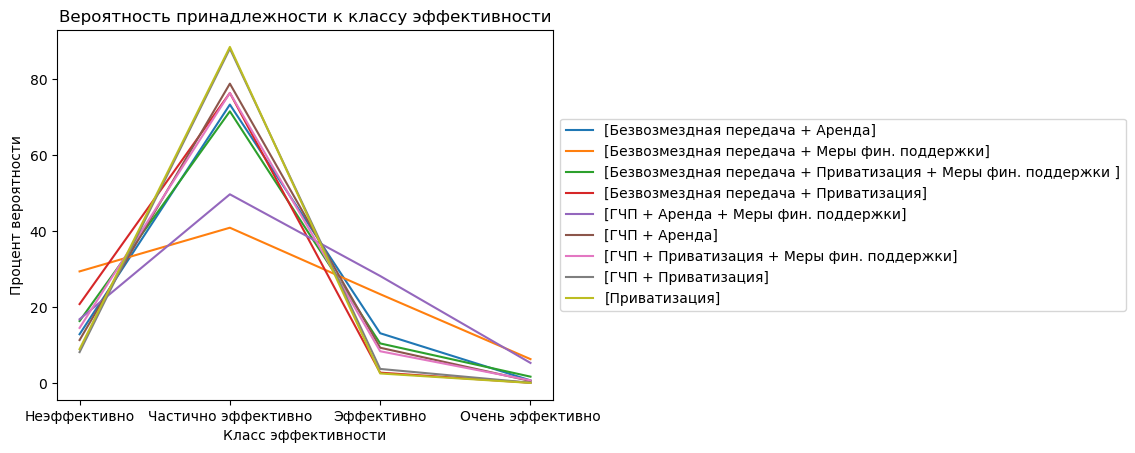

In [35]:
# Создаем график для каждой строки
for i in range(result.shape[0]):
    plt.plot(result[i], label=test.iloc[i,-1])

# Добавляем легенду справа от графика
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
#for handle in plt.legend(loc='center left', bbox_to_anchor=(1, 0.5)):
#    handle.set_marker('o')
axis_X = ['Неэффективно', 'Частично эффективно', 'Эффективно', 'Очень эффективно'] 
# Устанавливаем строковые значения для оси X
#x_labels = [f'Категория {i+1}' for i in range(result.shape[1])]
plt.xticks(ticks=np.arange(result.shape[1]), labels=axis_X)
# Заголовок и подписи осей
plt.title('Вероятность принадлежности к классу эффективности')
plt.xlabel('Класс эффективности')
plt.ylabel('Процент вероятности')
# Показываем график
plt.show()